# Segmentation par CNN patch-based — ISIC 2016

**Objectif** : Implémenter une approche intermédiaire entre le K-means (non supervisé, sans convolutions) et le U-Net (encodeur-décodeur avec skip connections). Le **CNN par patches** classifie chaque pixel en extrayant un voisinage local et en le passant dans un réseau convolutif simple.

**Positionnement dans la progression méthodologique :**

| Méthode | Supervision | Convolutions | Contexte spatial | Architecture |
|---------|------------|-------------|-----------------|-------------|
| K-means | Non | Non | Aucun (pixel isolé) | — |
| **CNN patch** | **Oui** | **Oui** | **Local (patch)** | **Conv + Dense** |
| U-Net | Oui | Oui | Global (image entière) | Encodeur-décodeur + skip |

**Principe** : Pour chaque pixel $(i, j)$, on extrait un patch carré centré sur ce pixel, puis un CNN classifie ce patch comme « lésion » ou « fond ». L'entraînement utilise des patches échantillonnés de manière équilibrée (50 % lésion, 50 % fond). L'inférence procède par fenêtre glissante avec interpolation.

**Hypothèse testée** : les convolutions apprises sur des patches locaux améliorent-elles la segmentation par rapport au clustering colorimétrique (K-means), et dans quelle mesure l'absence de contexte global limite-t-elle les performances par rapport au U-Net ?

---

In [1]:
import os, gc, time, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image
from pathlib import Path
from scipy.ndimage import label as ndimage_label
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Chemins ──
BASE = Path('.').resolve()
IMAGES_DIR = BASE / 'dataset_ISIC' / 'ISBI2016_ISIC_Part1_Training_Data'
MASKS_DIR  = BASE / 'dataset_ISIC' / 'ISBI2016_ISIC_Part1_Training_GroundTruth'
TEST_IMG_DIR  = BASE / 'dataset_ISIC' / 'ISBI2016_ISIC_Part1_Test_Data'
TEST_MASK_DIR = BASE / 'dataset_ISIC' / 'ISBI2016_ISIC_Part1_Test_GroundTruth'
SAVE_DIR = BASE / 'models'
SAVE_DIR.mkdir(exist_ok=True)

IMG_SIZE = 256

print(f'Train images : {len(list(IMAGES_DIR.glob("*.jpg")))}')
print(f'Test images  : {len(list(TEST_IMG_DIR.glob("*.jpg")))}')
print(f'GPU : {tf.config.list_physical_devices("GPU")}')
print('Setup OK')

Train images : 900
Test images  : 379
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Setup OK


In [2]:
# ═══════════════════════════════════════════════════════════════
# Fonctions utilitaires (identiques aux autres notebooks)
# ═══════════════════════════════════════════════════════════════

def load_img(path, size=IMG_SIZE):
    """Charge et redimensionne une image en [0, 1]."""
    img = Image.open(path).convert('RGB').resize((size, size), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0

def load_mask(path, size=IMG_SIZE):
    """Charge et binarise un masque."""
    m = Image.open(path).convert('L').resize((size, size), Image.NEAREST)
    return (np.array(m) > 127).astype(np.float32)

def dice(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    denom = np.sum(y_true) + np.sum(y_pred)
    return 2.0 * inter / denom if denom > 0 else 1.0

def iou(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - inter
    return inter / union if union > 0 else 1.0

def pixel_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    tp = np.sum(y_true * y_pred)
    fp = np.sum((1 - y_true) * y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score(y_true, y_pred):
    tp = np.sum(y_true * y_pred)
    fn = np.sum(y_true * (1 - y_pred))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def keep_largest_component(mask_bin):
    labeled, n = ndimage_label(mask_bin)
    if n <= 1:
        return mask_bin
    sizes = [np.sum(labeled == k) for k in range(1, n + 1)]
    largest = np.argmax(sizes) + 1
    return (labeled == largest).astype(np.float32)

def compute_all_metrics(gt, pred):
    return {
        'dice': dice(gt, pred), 'iou': iou(gt, pred),
        'accuracy': pixel_accuracy(gt, pred),
        'precision': precision_score(gt, pred),
        'recall': recall_score(gt, pred),
    }

print('Fonctions utilitaires chargees.')

Fonctions utilitaires chargees.


In [3]:
# ═══════════════════════════════════════════════════════════════
# Split stratifie (identique au notebook U-Net, seed=42)
# ═══════════════════════════════════════════════════════════════

def _compute_lesion_bin(mask_path):
    mask = np.array(Image.open(mask_path).convert('L'))
    ratio = float(np.mean(mask > 127))
    if ratio < 0.01:   return 0, ratio
    elif ratio < 0.05: return 1, ratio
    elif ratio < 0.10: return 2, ratio
    else:              return 3, ratio

def _merge_rare_bins(bins, min_count=4):
    bins = bins.copy()
    unique, counts = np.unique(bins, return_counts=True)
    for b, c in zip(unique, counts):
        if c < min_count:
            bins[bins == b] = b - 1 if b > 0 else b + 1
    return bins

def split_paths(scale=1.0, val_ratio=0.2, test_ratio=0.1, seed=SEED):
    imgs  = sorted([str(f) for f in IMAGES_DIR.glob('*.jpg')])
    masks = sorted([str(f) for f in MASKS_DIR.glob('*.png')])
    all_bins, all_ratios = [], []
    for mp in masks:
        b, r = _compute_lesion_bin(mp)
        all_bins.append(b); all_ratios.append(r)
    all_bins = np.array(all_bins)
    all_ratios = np.array(all_ratios)
    all_bins = _merge_rare_bins(all_bins)

    all_indices = np.arange(len(imgs))
    if scale < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=scale, random_state=seed)
        keep_idx, _ = next(sss.split(all_indices, all_bins))
        imgs   = [imgs[i] for i in keep_idx]
        masks  = [masks[i] for i in keep_idx]
        all_bins = all_bins[keep_idx]
        all_ratios = all_ratios[keep_idx]
        all_bins = _merge_rare_bins(all_bins)

    indices = np.arange(len(imgs))
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_ratio, random_state=seed)
    trainval_idx, test_idx = next(sss1.split(indices, all_bins))
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio/(1-test_ratio), random_state=seed)
    train_sub, val_sub = next(sss2.split(trainval_idx, all_bins[trainval_idx]))
    train_idx = trainval_idx[train_sub]
    val_idx   = trainval_idx[val_sub]

    for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
        b = all_bins[idx]
        dist = {i: np.sum(b==i) for i in range(4)}
        print(f'  {name:5s} n={len(idx):3d} | <1%:{dist[0]:2d}  1-5%:{dist[1]:2d}  5-10%:{dist[2]:2d}  >10%:{dist[3]:2d}')

    to_list = lambda idx: ([imgs[i] for i in idx], [masks[i] for i in idx])
    return to_list(train_idx), to_list(val_idx), to_list(test_idx)

(train_img, train_mask), (val_img, val_mask), (test_img, test_mask) = split_paths(scale=1.0)
print(f'\nTrain: {len(train_img)} | Val: {len(val_img)} | Test: {len(test_img)}')

  Train n=630 | <1%: 0  1-5%:51  5-10%:100  >10%:479
  Val   n=180 | <1%: 0  1-5%:15  5-10%:29  >10%:136
  Test  n= 90 | <1%: 0  1-5%: 7  5-10%:15  >10%:68

Train: 630 | Val: 180 | Test: 90


## 1. Extraction des patches

Pour chaque image d'entraînement redimensionnée à $256 \times 256$ :
1. On identifie les pixels « lésion » ($M_{ij} = 1$) et « fond » ($M_{ij} = 0$) à distance suffisante des bords
2. On échantillonne $n$ pixels de chaque classe (échantillonnage **équilibré**)
3. Pour chaque pixel sélectionné, on extrait le patch carré $P \times P$ centré sur ce pixel

L'échantillonnage équilibré (50/50) est essentiel car le fond domine la plupart des images ($\rho$ médian = 21 %), ce qui biaiserait l'entraînement vers la classe majoritaire.

**Paramètres :**
- `patch_size` $P \in \{32, 48, 64\}$ : taille du voisinage local (étude d'ablation)
- `n_patches_per_class` = 100 par image → ~200 patches/image → ~126 000 patches au total

In [4]:
# ═══════════════════════════════════════════════════════════════
# Extraction de patches equilbres (lesion / fond)
# ═══════════════════════════════════════════════════════════════

def extract_patches_from_image(img, mask, patch_size, n_per_class=100):
    """
    Extrait des patches equilibres depuis une image.
    img  : (H, W, 3) float32 [0,1]
    mask : (H, W) float32 {0, 1}
    Retourne : patches (N, P, P, 3), labels (N,)
    """
    h, w = mask.shape
    half = patch_size // 2

    # Coordonnees valides (loin des bords)
    valid = np.zeros_like(mask, dtype=bool)
    valid[half:h-half, half:w-half] = True

    lesion_yx = np.argwhere(valid & (mask == 1))
    bg_yx     = np.argwhere(valid & (mask == 0))

    patches, labels = [], []

    for coords, label in [(lesion_yx, 1), (bg_yx, 0)]:
        if len(coords) == 0:
            continue
        n_sample = min(n_per_class, len(coords))
        idx = np.random.choice(len(coords), n_sample, replace=False)
        for y, x in coords[idx]:
            patch = img[y-half:y+half, x-half:x+half]
            if patch.shape == (patch_size, patch_size, 3):
                patches.append(patch)
                labels.append(label)

    return np.array(patches, dtype=np.float32), np.array(labels, dtype=np.float32)


def build_patch_dataset(img_paths, mask_paths, patch_size, n_per_class=100):
    """
    Construit le dataset de patches a partir de la liste d'images.
    """
    all_patches, all_labels = [], []
    for i, (ip, mp) in enumerate(zip(img_paths, mask_paths)):
        img = load_img(ip)
        mask = load_mask(mp)
        patches, labels = extract_patches_from_image(img, mask, patch_size, n_per_class)
        all_patches.append(patches)
        all_labels.append(labels)
        if (i + 1) % 100 == 0:
            print(f'  {i+1}/{len(img_paths)} images...')

    X = np.concatenate(all_patches, axis=0)
    y = np.concatenate(all_labels, axis=0)

    # Shuffle
    perm = np.random.permutation(len(X))
    X, y = X[perm], y[perm]

    print(f'Dataset : {len(X)} patches ({patch_size}x{patch_size})')
    print(f'  Lesion : {int(np.sum(y == 1))} ({np.mean(y)*100:.1f}%)')
    print(f'  Fond   : {int(np.sum(y == 0))} ({(1-np.mean(y))*100:.1f}%)')
    return X, y

print('Fonctions d\'extraction definies.')

Fonctions d'extraction definies.


In [5]:
# ── Extraction des patches pour le patch_size principal (48) ──

PATCH_SIZE = 48
N_PER_CLASS = 100

print(f'Extraction des patches (P={PATCH_SIZE}, n_per_class={N_PER_CLASS})...')
print(f'Estimation : ~{len(train_img) * 2 * N_PER_CLASS:,} patches')

t0 = time.time()
X_train, y_train = build_patch_dataset(train_img, train_mask, PATCH_SIZE, N_PER_CLASS)
print(f'Temps d\'extraction : {time.time()-t0:.1f}s')

# Validation : extraire aussi des patches pour le suivi
X_val, y_val = build_patch_dataset(val_img, val_mask, PATCH_SIZE, N_PER_CLASS)

print(f'\nTrain : {X_train.shape}  |  Val : {X_val.shape}')

Extraction des patches (P=48, n_per_class=100)...
Estimation : ~126,000 patches
  100/630 images...
  200/630 images...
  300/630 images...
  400/630 images...
  500/630 images...
  600/630 images...
Dataset : 125618 patches (48x48)
  Lesion : 63000 (50.2%)
  Fond   : 62618 (49.8%)
Temps d'extraction : 30.6s
  100/180 images...
Dataset : 35965 patches (48x48)
  Lesion : 18000 (50.0%)
  Fond   : 17965 (50.0%)

Train : (125618, 48, 48, 3)  |  Val : (35965, 48, 48, 3)


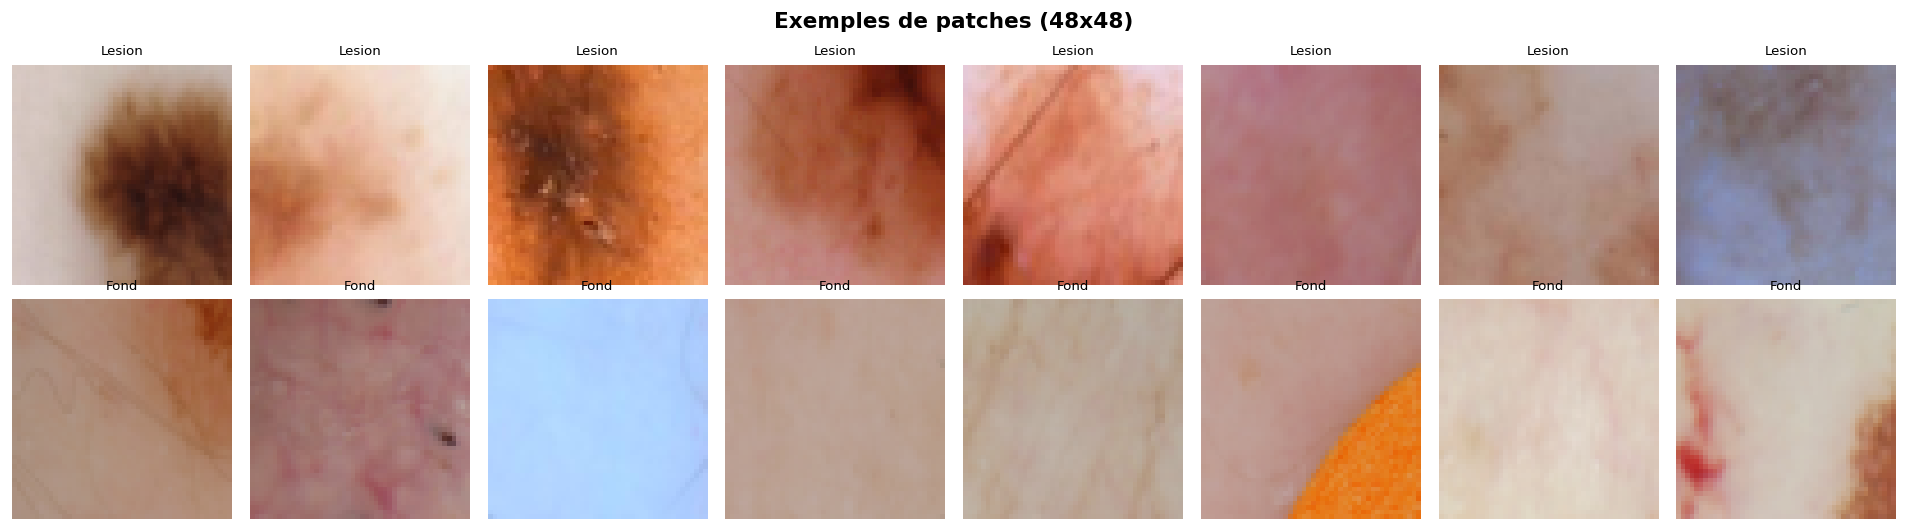

In [6]:
# ═══════════════════════════════════════════════════════════════
# Visualisation de patches echantillonnes
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
fig.suptitle(f'Exemples de patches ({PATCH_SIZE}x{PATCH_SIZE})', fontsize=13, fontweight='bold')

# Ligne 1 : patches lesion
lesion_idx = np.where(y_train == 1)[0][:8]
for i, idx in enumerate(lesion_idx):
    axes[0, i].imshow(X_train[idx])
    axes[0, i].set_title('Lesion', fontsize=8)
    axes[0, i].axis('off')

# Ligne 2 : patches fond
bg_idx = np.where(y_train == 0)[0][:8]
for i, idx in enumerate(bg_idx):
    axes[1, i].imshow(X_train[idx])
    axes[1, i].set_title('Fond', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 2. Architecture du CNN

Le CNN est volontairement **simple** : 3 blocs convolutifs suivis de couches denses. Cette architecture n'a **pas** de structure encodeur-décodeur et ne voit que le patch local — c'est précisément ce qui le distingue du U-Net.

**Architecture :**
```
Input (P x P x 3)
  → Conv2D(32, 3x3, ReLU) → Conv2D(32, 3x3, ReLU) → MaxPool(2x2)
  → Conv2D(64, 3x3, ReLU) → Conv2D(64, 3x3, ReLU) → MaxPool(2x2)
  → Conv2D(128, 3x3, ReLU) → MaxPool(2x2)
  → GlobalAveragePooling2D
  → Dense(64, ReLU) → Dropout(0.5)
  → Dense(1, Sigmoid)
```

Le `GlobalAveragePooling2D` rend le modèle agnostique à la taille exacte du patch (utile pour l'ablation sur $P$).

In [7]:
# ═══════════════════════════════════════════════════════════════
# Construction du CNN patch classifier
# ═══════════════════════════════════════════════════════════════

def build_patch_cnn(patch_size, name='patch_cnn'):
    inputs = layers.Input(shape=(patch_size, patch_size, 3))

    # Bloc 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu', kernel_initializer='he_normal')(inputs)
    x = layers.Conv2D(32, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.MaxPool2D(2)(x)

    # Bloc 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.MaxPool2D(2)(x)

    # Bloc 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.MaxPool2D(2)(x)

    # Classification
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name=name)
    return model

model = build_patch_cnn(PATCH_SIZE)
model.summary()

I0000 00:00:1773393568.045603    1111 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13366 MB memory:  -> device: 0, name: NVIDIA A2, pci bus id: 0000:18:00.0, compute capability: 8.6


Model: "patch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,745 (577.13 KB)

 Trainable params: 147,745 (577.13 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entraînement

**Protocole :**
- Optimiseur : Adam ($\eta = 10^{-4}$), identique au U-Net
- Loss : Binary Cross-Entropy (classification binaire standard)
- Epochs : 30, avec early stopping (patience = 5, monitor = `val_loss`)
- Batch size : 64
- Data augmentation : flips horizontaux et verticaux aléatoires sur les patches

In [8]:
# ═══════════════════════════════════════════════════════════════                                                                                          
  # Augmentation sur patches + creation des tf.data.Dataset                    
  # ═══════════════════════════════════════════════════════════════                                                                                          
                                                                                                                                                           
def augment_patch(image, label):                                                                        
  image = tf.image.random_flip_left_right(image)                                                                                                         
  image = tf.image.random_flip_up_down(image)                                                                                                            
  return image, label                                                                                                                                    

BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_patch_ds(X, y, augment=False, batch_size=BATCH_SIZE):                                                                                             
  """Cree un tf.data.Dataset en gardant les donnees sur CPU."""
  with tf.device('/cpu:0'):
      ds = tf.data.Dataset.from_tensor_slices((X, y))
  if augment:
      ds = ds.shuffle(len(X)).map(augment_patch, num_parallel_calls=AUTOTUNE)
  return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_patch_ds(X_train, y_train, augment=True)
val_ds   = make_patch_ds(X_val, y_val, augment=False)

print(f'Train batches : {len(train_ds)}  |  Val batches : {len(val_ds)}')

Train batches : 1963  |  Val batches : 562


In [9]:
# ═══════════════════════════════════════════════════════════════
# Entrainement du CNN patch classifier
# ═══════════════════════════════════════════════════════════════

EPOCHS = 30
PATIENCE = 5

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=PATIENCE, monitor='val_loss',
        restore_best_weights=True, verbose=1
    )
]

print(f'Entrainement du CNN (P={PATCH_SIZE}, {model.count_params():,} params)...')
t0 = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2)
train_time = time.time() - t0
print(f'\nTemps d\'entrainement : {train_time:.0f}s ({train_time/60:.1f} min)')

# Sauvegarder le modele
model_path = SAVE_DIR / f'patch_cnn_p{PATCH_SIZE}.keras'
model.save(model_path)
print(f'Modele sauvegarde : {model_path}')

Entrainement du CNN (P=48, 147,745 params)...
Epoch 1/30


I0000 00:00:1773393584.325142    1485 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1963/1963 - 61s - 31ms/step - accuracy: 0.8395 - loss: 0.3825 - val_accuracy: 0.8775 - val_loss: 0.3022
Epoch 2/30
1963/1963 - 38s - 19ms/step - accuracy: 0.8771 - loss: 0.3037 - val_accuracy: 0.8762 - val_loss: 0.3038
Epoch 3/30
1963/1963 - 41s - 21ms/step - accuracy: 0.8889 - loss: 0.2763 - val_accuracy: 0.8957 - val_loss: 0.2529
Epoch 4/30
1963/1963 - 38s - 19ms/step - accuracy: 0.8938 - loss: 0.2641 - val_accuracy: 0.9017 - val_loss: 0.2445
Epoch 5/30
1963/1963 - 37s - 19ms/step - accuracy: 0.8980 - loss: 0.2559 - val_accuracy: 0.8956 - val_loss: 0.2490
Epoch 6/30
1963/1963 - 41s - 21ms/step - accuracy: 0.9003 - loss: 0.2497 - val_accuracy: 0.9032 - val_loss: 0.2371
Epoch 7/30
1963/1963 - 41s - 21ms/step - accuracy: 0.9017 - loss: 0.2450 - val_accuracy: 0.9027 - val_loss: 0.2379
Epoch 8/30
1963/1963 - 41s - 21ms/step - accuracy: 0.9040 - loss: 0.2409 - val_accuracy: 0.9055 - val_loss: 0.2347
Epoch 9/30
1963/1963 - 38s - 20ms/step - accuracy: 0.9051 - loss: 0.2383 - val_accuracy: 0.

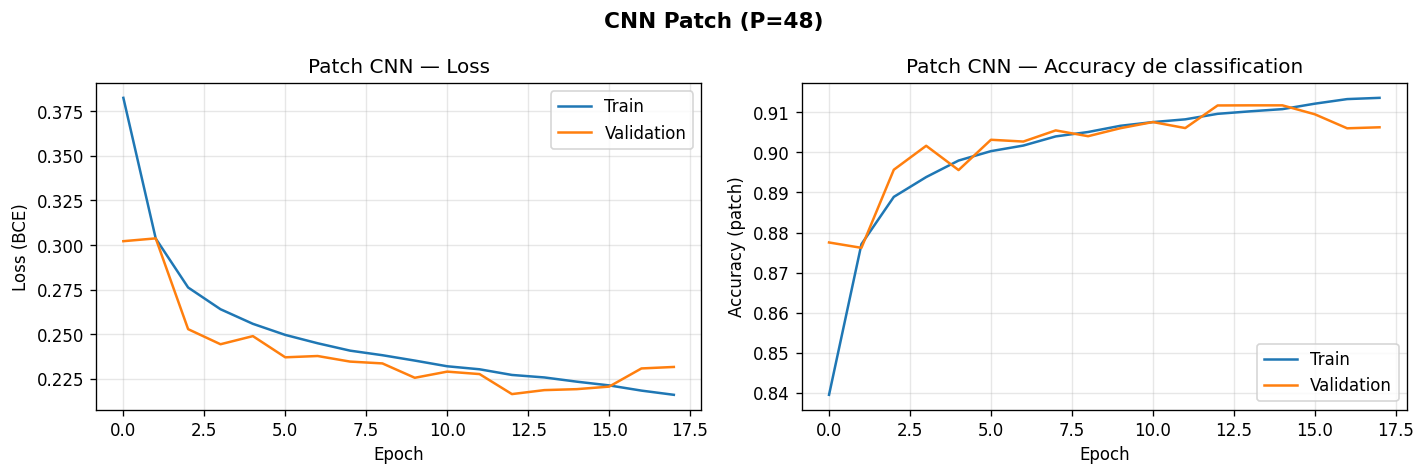

Meilleure accuracy de classification (val) : 0.9117


In [10]:
# ═══════════════════════════════════════════════════════════════
# Courbes d'apprentissage
# ═══════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss (BCE)')
ax1.set_title('Patch CNN — Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['accuracy'], label='Train')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (patch)')
ax2.set_title('Patch CNN — Accuracy de classification'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'CNN Patch (P={PATCH_SIZE})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f'Meilleure accuracy de classification (val) : {best_val_acc:.4f}')

## 4. Inférence par fenêtre glissante

Pour reconstruire un masque de segmentation complet à partir du CNN patch-based :
1. On parcourt l'image avec une **fenêtre glissante** de pas `stride`
2. Pour chaque position, on extrait le patch et on prédit la probabilité « lésion » pour le pixel central
3. On obtient une grille de probabilités à résolution réduite
4. On **interpole** (bilinéaire) cette grille à la résolution originale $256 \times 256$
5. On binarise au seuil 0.5 et on applique un **post-traitement** (plus grande composante connexe)

**Limitation fondamentale** : cette procédure est lente car elle nécessite $\left\lfloor\frac{H - P}{s}\right\rfloor \times \left\lfloor\frac{W - P}{s}\right\rfloor$ évaluations du CNN par image, contre **une seule** pour le U-Net.

In [11]:
# ═══════════════════════════════════════════════════════════════
# Inference par fenetre glissante
# ═══════════════════════════════════════════════════════════════

def predict_segmentation(model, img, patch_size, stride=8, batch_size=256):
    """
    Predit un masque de segmentation par fenetre glissante.
    img : (H, W, 3) float32 [0, 1]
    Retourne : prob_map (H, W) float32 [0, 1]
    """
    h, w = img.shape[:2]
    half = patch_size // 2

    # Positions de la grille
    ys = np.arange(half, h - half, stride)
    xs = np.arange(half, w - half, stride)

    # Extraire tous les patches
    patches = []
    for y in ys:
        for x in xs:
            patches.append(img[y-half:y+half, x-half:x+half])
    patches = np.array(patches, dtype=np.float32)

    # Prediction par batch
    preds = model.predict(patches, batch_size=batch_size, verbose=0).flatten()

    # Reconstruire la grille de probabilites
    grid = preds.reshape(len(ys), len(xs))

    # Interpoler a la resolution complete
    grid_tensor = tf.constant(grid[np.newaxis, ..., np.newaxis], dtype=tf.float32)
    prob_map = tf.image.resize(grid_tensor, (h, w), method='bilinear')[0, :, :, 0].numpy()

    return prob_map


def segment_with_cnn(model, img, patch_size, stride=8, threshold=0.5):
    """
    Pipeline complet : inference + binarisation + post-traitement.
    """
    prob_map = predict_segmentation(model, img, patch_size, stride)
    mask_bin = (prob_map >= threshold).astype(np.float32)
    mask_bin = keep_largest_component(mask_bin)
    return mask_bin, prob_map

print('Fonctions d\'inference definies.')

Fonctions d'inference definies.


## 5. Évaluation sur le jeu de validation (180 images)

On évalue le CNN patch-based sur les 180 images de validation avec les mêmes métriques que les autres approches : DSC, IoU, Accuracy, Precision, Recall.

In [12]:
# ═══════════════════════════════════════════════════════════════
# Evaluation sur le jeu de validation
# ═══════════════════════════════════════════════════════════════

STRIDE = 8

def evaluate_on_set(model, img_paths, mask_paths, patch_size, stride=STRIDE, set_name='Val'):
    results = []
    t0 = time.time()
    for i, (ip, mp) in enumerate(zip(img_paths, mask_paths)):
        img = load_img(ip)
        gt  = load_mask(mp)
        rho = float(np.mean(gt))

        pred_bin, prob_map = segment_with_cnn(model, img, patch_size, stride)
        metrics = compute_all_metrics(gt, pred_bin)
        metrics['image'] = Path(ip).stem
        metrics['rho'] = rho
        results.append(metrics)

        if (i + 1) % 30 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i+1) * (len(img_paths) - i - 1)
            print(f'  {i+1}/{len(img_paths)} ({elapsed:.0f}s, ETA ~{eta:.0f}s)')

    elapsed = time.time() - t0
    df = pd.DataFrame(results)
    print(f'\n{set_name} ({len(df)} images) en {elapsed:.0f}s ({elapsed/len(df):.2f}s/image)')
    for col in ['dice', 'iou', 'accuracy', 'precision', 'recall']:
        print(f'  {col.upper():<10} {df[col].mean():.4f} +/- {df[col].std():.4f}')
    print(f'  Echecs (DSC<0.5) : {(df["dice"] < 0.5).sum()}')
    return df

print(f'Evaluation sur validation ({len(val_img)} images, stride={STRIDE})...')
df_val = evaluate_on_set(model, val_img, val_mask, PATCH_SIZE, set_name='Validation')

Evaluation sur validation (180 images, stride=8)...
  30/180 (13s, ETA ~67s)
  60/180 (20s, ETA ~39s)
  90/180 (26s, ETA ~26s)
  120/180 (33s, ETA ~16s)
  150/180 (39s, ETA ~8s)
  180/180 (45s, ETA ~0s)

Validation (180 images) en 45s (0.25s/image)
  DICE       0.7308 +/- 0.1455
  IOU        0.5934 +/- 0.1572
  ACCURACY   0.8581 +/- 0.1142
  PRECISION  0.6312 +/- 0.1649
  RECALL     0.9319 +/- 0.1732
  Echecs (DSC<0.5) : 11


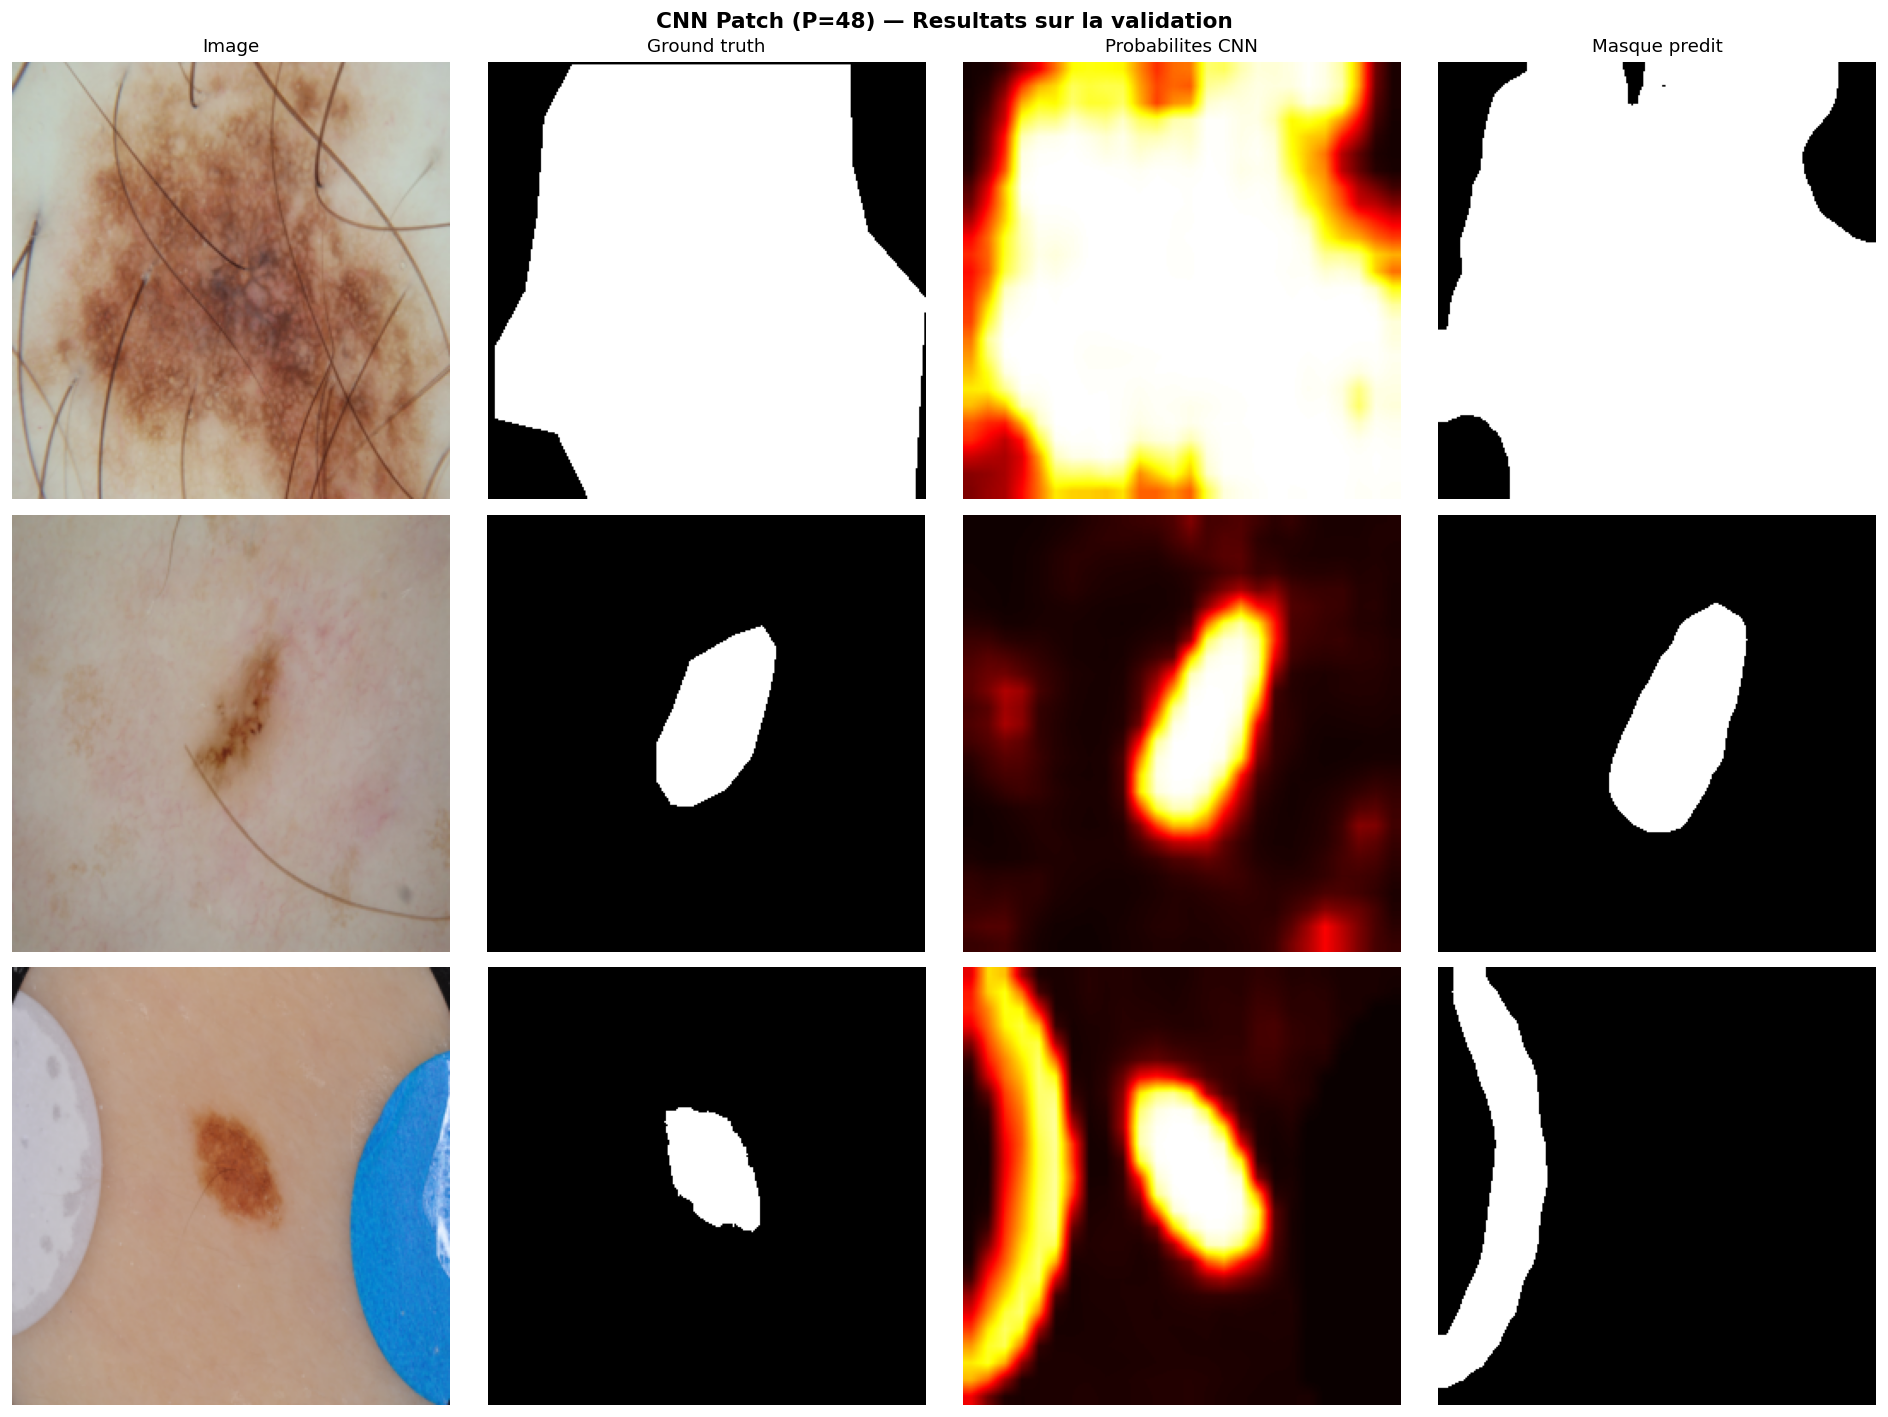

In [13]:
# ═══════════════════════════════════════════════════════════════
# Visualisations qualitatives sur la validation
# ═══════════════════════════════════════════════════════════════

# Selectionner 3 cas : meilleur, median, pire DSC
idx_best   = df_val['dice'].idxmax()
idx_worst  = df_val['dice'].idxmin()
idx_median = (df_val['dice'] - df_val['dice'].median()).abs().idxmin()

cases = [
    ('Meilleur cas', idx_best),
    ('Cas median', idx_median),
    ('Pire cas', idx_worst),
]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
col_titles = ['Image', 'Ground truth', 'Probabilites CNN', 'Masque predit']

for row, (title, idx) in enumerate(cases):
    ip, mp = val_img[idx], val_mask[idx]
    img = load_img(ip)
    gt  = load_mask(mp)
    pred_bin, prob_map = segment_with_cnn(model, img, PATCH_SIZE, STRIDE)

    r = df_val.iloc[idx]

    axes[row, 0].imshow(img)
    axes[row, 0].set_ylabel(f'{title}\nDSC={r["dice"]:.3f}', fontsize=10, fontweight='bold')

    axes[row, 1].imshow(gt, cmap='gray', vmin=0, vmax=1)

    axes[row, 2].imshow(prob_map, cmap='hot', vmin=0, vmax=1)

    axes[row, 3].imshow(pred_bin, cmap='gray', vmin=0, vmax=1)

    for j in range(4):
        axes[row, j].axis('off')
        if row == 0:
            axes[row, j].set_title(col_titles[j], fontsize=11)

plt.suptitle(f'CNN Patch (P={PATCH_SIZE}) — Resultats sur la validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Étude d'ablation : taille du patch $P$

La taille du patch $P$ contrôle le **champ réceptif** du CNN. Un patch plus grand fournit plus de contexte mais :
- augmente le nombre de paramètres et le temps d'entraînement
- risque d'inclure du fond non informatif

On compare $P \in \{32, 48, 64\}$ pour quantifier cet effet.

In [14]:
# ═══════════════════════════════════════════════════════════════
# Etude d'ablation : patch_size = 32, 48, 64
# ═══════════════════════════════════════════════════════════════

PATCH_SIZES = [32, 48, 64]
ablation_results = {}

for ps in PATCH_SIZES:
    print(f'\n{"="*60}')
    print(f'  Patch size = {ps}')
    print(f'{"="*60}')

    # Verifier si le modele existe deja
    cached_path = SAVE_DIR / f'patch_cnn_p{ps}.keras'

    if ps == PATCH_SIZE and model is not None:
        # Reutiliser le modele deja entraine
        print('  -> Reutilisation du modele deja entraine')
        m = model
        h = history.history
        t = train_time
    else:
        # Extraire les patches
        print(f'  Extraction des patches (P={ps})...')
        X_tr, y_tr = build_patch_dataset(train_img, train_mask, ps, N_PER_CLASS)
        X_vl, y_vl = build_patch_dataset(val_img, val_mask, ps, N_PER_CLASS)

        # Creer les datasets
        ds_tr = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(len(X_tr))
        ds_tr = ds_tr.map(augment_patch, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
        ds_vl = tf.data.Dataset.from_tensor_slices((X_vl, y_vl)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

        # Construire et entrainer
        m = build_patch_cnn(ps, name=f'patch_cnn_p{ps}')
        m.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
        cb = [tf.keras.callbacks.EarlyStopping(patience=PATIENCE, monitor='val_loss', restore_best_weights=True)]

        print(f'  Entrainement ({m.count_params():,} params)...')
        t0 = time.time()
        hist = m.fit(ds_tr, validation_data=ds_vl, epochs=EPOCHS, callbacks=cb, verbose=0)
        t = time.time() - t0
        h = hist.history

        m.save(SAVE_DIR / f'patch_cnn_p{ps}.keras')
        del X_tr, y_tr, X_vl, y_vl; gc.collect()

    # Evaluer sur la validation (segmentation)
    print(f'  Evaluation sur validation...')
    stride = max(8, ps // 6)  # stride adapte
    df_res = evaluate_on_set(m, val_img, val_mask, ps, stride=stride, set_name=f'P={ps}')

    ablation_results[ps] = {
        'patch_size': ps,
        'params': m.count_params(),
        'train_time_s': round(t, 1),
        'best_val_acc': round(max(h['val_accuracy']), 4),
        'n_epochs': len(h['loss']),
        'val_dice_mean': round(df_res['dice'].mean(), 4),
        'val_dice_std': round(df_res['dice'].std(), 4),
        'val_iou_mean': round(df_res['iou'].mean(), 4),
        'val_iou_std': round(df_res['iou'].std(), 4),
        'val_acc_mean': round(df_res['accuracy'].mean(), 4),
        'n_failures': int((df_res['dice'] < 0.5).sum()),
        'df': df_res,
    }

    if ps != PATCH_SIZE:
        del m; K.clear_session(); gc.collect()

print(f'\n{"="*60}')
print('RESULTATS ABLATION')
print(f'{"="*60}')
print(f'{"P":>4} {"Params":>10} {"Temps":>8} {"Epochs":>7} {"Patch Acc":>10} {"DSC":>14} {"IoU":>14} {"Echecs":>7}')
for ps, r in ablation_results.items():
    print(f'{ps:>4} {r["params"]:>10,} {r["train_time_s"]:>7.0f}s {r["n_epochs"]:>6} '
          f'{r["best_val_acc"]:>10.4f} '
          f'{r["val_dice_mean"]:.3f}+/-{r["val_dice_std"]:.3f} '
          f'{r["val_iou_mean"]:.3f}+/-{r["val_iou_std"]:.3f} '
          f'{r["n_failures"]:>6}')


  Patch size = 32
  Extraction des patches (P=32)...
  100/630 images...
  200/630 images...
  300/630 images...
  400/630 images...
  500/630 images...
  600/630 images...
Dataset : 125737 patches (32x32)
  Lesion : 63000 (50.1%)
  Fond   : 62737 (49.9%)
  100/180 images...
Dataset : 36000 patches (32x32)
  Lesion : 18000 (50.0%)
  Fond   : 18000 (50.0%)
  Entrainement (147,745 params)...
  Evaluation sur validation...
  30/180 (10s, ETA ~48s)
  60/180 (15s, ETA ~30s)
  90/180 (21s, ETA ~21s)
  120/180 (26s, ETA ~13s)
  150/180 (33s, ETA ~7s)
  180/180 (39s, ETA ~0s)

P=32 (180 images) en 39s (0.22s/image)
  DICE       0.7621 +/- 0.1419
  IOU        0.6334 +/- 0.1585
  ACCURACY   0.8768 +/- 0.1206
  PRECISION  0.6834 +/- 0.1613
  RECALL     0.9275 +/- 0.1698
  Echecs (DSC<0.5) : 9

  Patch size = 48
  -> Reutilisation du modele deja entraine
  Evaluation sur validation...
  30/180 (9s, ETA ~45s)
  60/180 (16s, ETA ~32s)
  90/180 (23s, ETA ~23s)
  120/180 (30s, ETA ~15s)
  150/180 (37

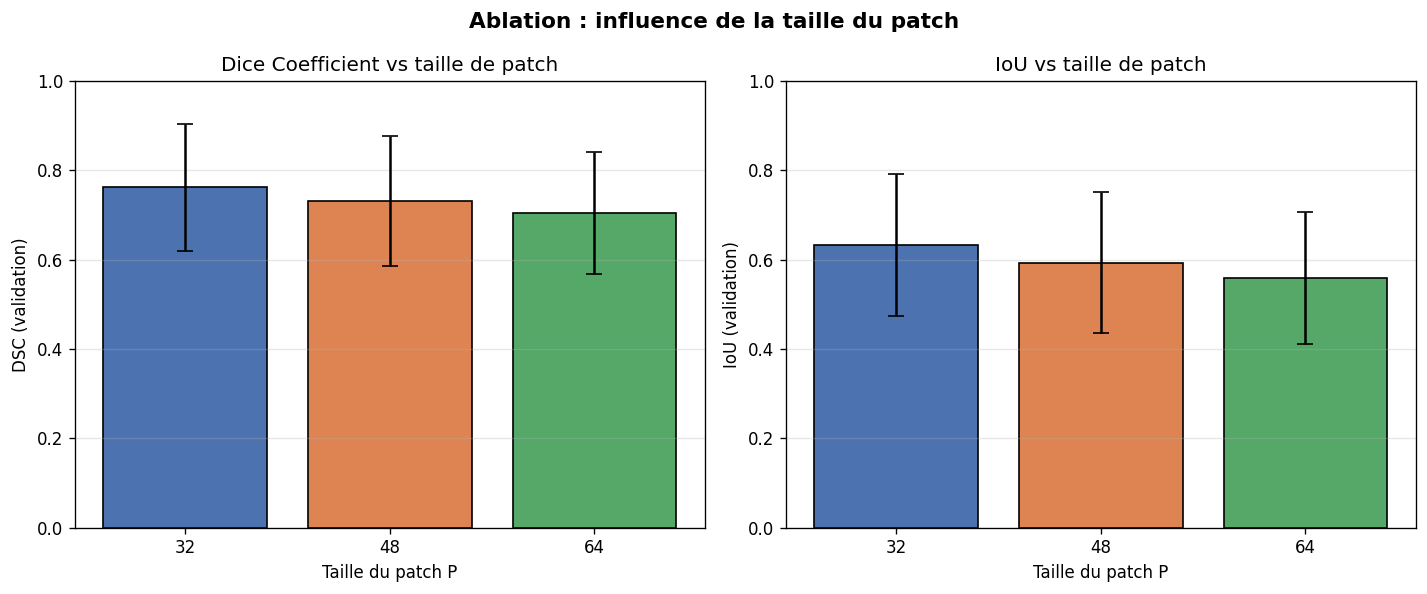

In [15]:
# ═══════════════════════════════════════════════════════════════
# Graphique comparatif des patch sizes
# ═══════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ps_list = list(ablation_results.keys())
dice_means = [ablation_results[p]['val_dice_mean'] for p in ps_list]
dice_stds  = [ablation_results[p]['val_dice_std'] for p in ps_list]
iou_means  = [ablation_results[p]['val_iou_mean'] for p in ps_list]
iou_stds   = [ablation_results[p]['val_iou_std'] for p in ps_list]

ax1.bar([str(p) for p in ps_list], dice_means, yerr=dice_stds, capsize=5,
        color=['#4c72b0', '#dd8452', '#55a868'], edgecolor='black')
ax1.set_xlabel('Taille du patch P')
ax1.set_ylabel('DSC (validation)')
ax1.set_title('Dice Coefficient vs taille de patch')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

ax2.bar([str(p) for p in ps_list], iou_means, yerr=iou_stds, capsize=5,
        color=['#4c72b0', '#dd8452', '#55a868'], edgecolor='black')
ax2.set_xlabel('Taille du patch P')
ax2.set_ylabel('IoU (validation)')
ax2.set_title('IoU vs taille de patch')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Ablation : influence de la taille du patch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Évaluation sur le jeu de test officiel ISBI 2016 (379 images)

On évalue le meilleur CNN patch (selon l'ablation) sur le jeu de test officiel, identique à l'évaluation du U-Net, pour une comparaison équitable.

In [16]:
# ═══════════════════════════════════════════════════════════════
# Evaluation sur le test set officiel ISBI 2016 (379 images)
# ═══════════════════════════════════════════════════════════════

# Selectionner le meilleur patch_size
best_ps = max(ablation_results, key=lambda p: ablation_results[p]['val_dice_mean'])
print(f'Meilleur patch_size selon validation : P={best_ps} (DSC={ablation_results[best_ps]["val_dice_mean"]:.4f})')

# Charger le modele
best_model = tf.keras.models.load_model(SAVE_DIR / f'patch_cnn_p{best_ps}.keras')
best_stride = max(8, best_ps // 6)

# Chemins du test set
test_official_img  = sorted([str(f) for f in TEST_IMG_DIR.glob('*.jpg')])
test_official_mask = sorted([str(f) for f in TEST_MASK_DIR.glob('*.png')])
print(f'Test set officiel : {len(test_official_img)} images')

print(f'\nEvaluation en cours (stride={best_stride})...')
df_test = evaluate_on_set(best_model, test_official_img, test_official_mask,
                          best_ps, stride=best_stride, set_name='Test ISBI 2016')

Meilleur patch_size selon validation : P=32 (DSC=0.7621)
Test set officiel : 379 images

Evaluation en cours (stride=8)...
  30/379 (8s, ETA ~90s)
  60/379 (14s, ETA ~75s)
  90/379 (20s, ETA ~64s)
  120/379 (27s, ETA ~58s)
  150/379 (35s, ETA ~54s)
  180/379 (46s, ETA ~51s)
  210/379 (52s, ETA ~42s)
  240/379 (58s, ETA ~34s)
  270/379 (64s, ETA ~26s)
  300/379 (70s, ETA ~18s)
  330/379 (76s, ETA ~11s)
  360/379 (82s, ETA ~4s)

Test ISBI 2016 (379 images) en 86s (0.23s/image)
  DICE       0.7605 +/- 0.1754
  IOU        0.6390 +/- 0.1840
  ACCURACY   0.8676 +/- 0.1291
  PRECISION  0.6860 +/- 0.1913
  RECALL     0.9211 +/- 0.1843
  Echecs (DSC<0.5) : 29


In [17]:
# ═══════════════════════════════════════════════════════════════
# Analyse par sous-groupes de taille de lesion (test set)
# ═══════════════════════════════════════════════════════════════

def size_class(rho):
    if rho < 0.05:  return 'Petites (<5%)'
    elif rho < 0.10: return 'Moyennes (5-10%)'
    else:            return 'Grandes (>10%)'

df_test['size_class'] = df_test['rho'].apply(size_class)

print('Analyse par sous-groupes (test set officiel) :')
print('=' * 75)
print(f'{"Sous-groupe":<20} {"n":>4} {"DSC":>18} {"IoU":>18} {"Echecs":>8}')
print('=' * 75)

for sc in ['Petites (<5%)', 'Moyennes (5-10%)', 'Grandes (>10%)']:
    sub = df_test[df_test['size_class'] == sc]
    if len(sub) == 0: continue
    n_fail = (sub['dice'] < 0.5).sum()
    print(f'{sc:<20} {len(sub):>4} '
          f'{sub["dice"].mean():.3f} +/- {sub["dice"].std():.3f}   '
          f'{sub["iou"].mean():.3f} +/- {sub["iou"].std():.3f}   '
          f'{n_fail:>3d}')

Analyse par sous-groupes (test set officiel) :
Sous-groupe             n                DSC                IoU   Echecs
Petites (<5%)          40 0.590 +/- 0.250   0.455 +/- 0.214     9
Moyennes (5-10%)       47 0.708 +/- 0.184   0.572 +/- 0.177     6
Grandes (>10%)        292 0.792 +/- 0.144   0.675 +/- 0.162    14


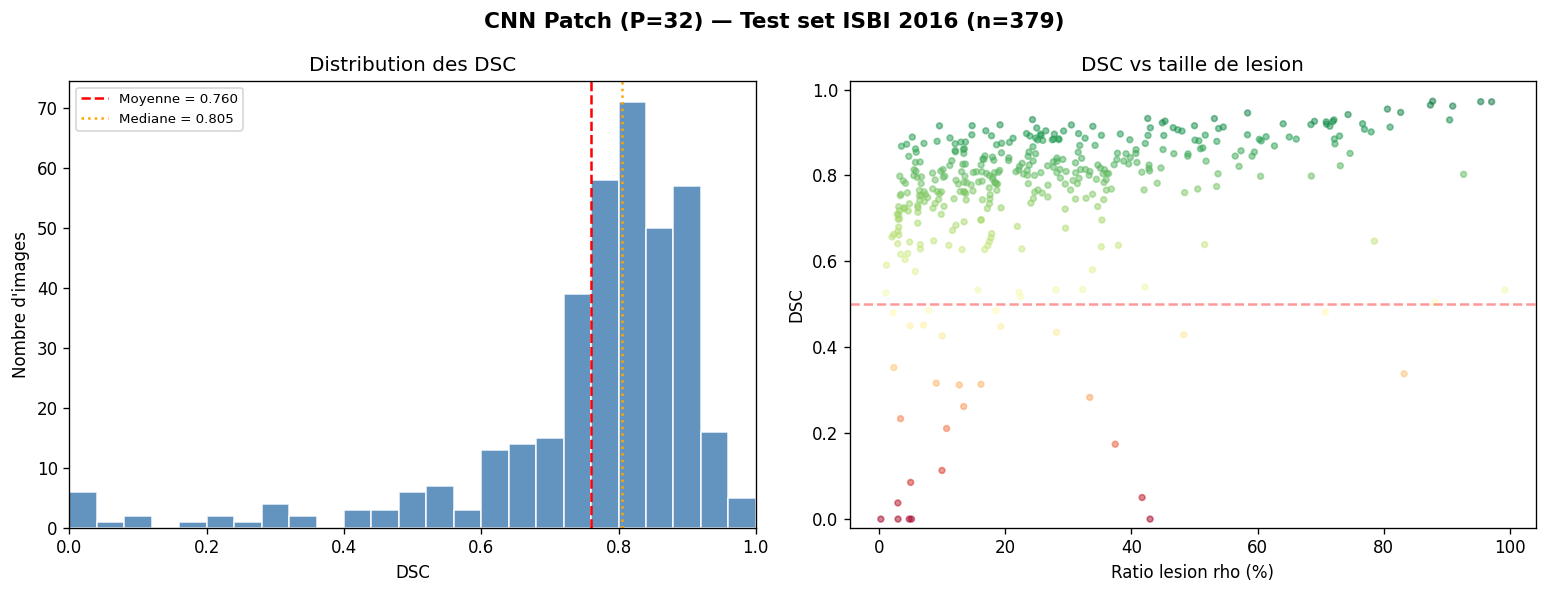

In [18]:
# ═══════════════════════════════════════════════════════════════
# Distribution des DSC sur le test set
# ═══════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme
bins = np.linspace(0, 1, 26)
ax1.hist(df_test['dice'], bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(df_test['dice'].mean(), color='red', linestyle='--',
            label=f'Moyenne = {df_test["dice"].mean():.3f}')
ax1.axvline(df_test['dice'].median(), color='orange', linestyle=':',
            label=f'Mediane = {df_test["dice"].median():.3f}')
ax1.set_xlabel('DSC'); ax1.set_ylabel('Nombre d\'images')
ax1.set_title('Distribution des DSC'); ax1.legend(fontsize=8); ax1.set_xlim(0, 1)

# DSC vs rho
sc = ax2.scatter(df_test['rho'] * 100, df_test['dice'], s=12, alpha=0.5,
                 c=df_test['dice'], cmap='RdYlGn', vmin=0, vmax=1)
ax2.axhline(0.5, color='red', linestyle='--', alpha=0.4)
ax2.set_xlabel('Ratio lesion rho (%)'); ax2.set_ylabel('DSC')
ax2.set_title('DSC vs taille de lesion'); ax2.set_ylim(-0.02, 1.02)

plt.suptitle(f'CNN Patch (P={best_ps}) — Test set ISBI 2016 (n={len(df_test)})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

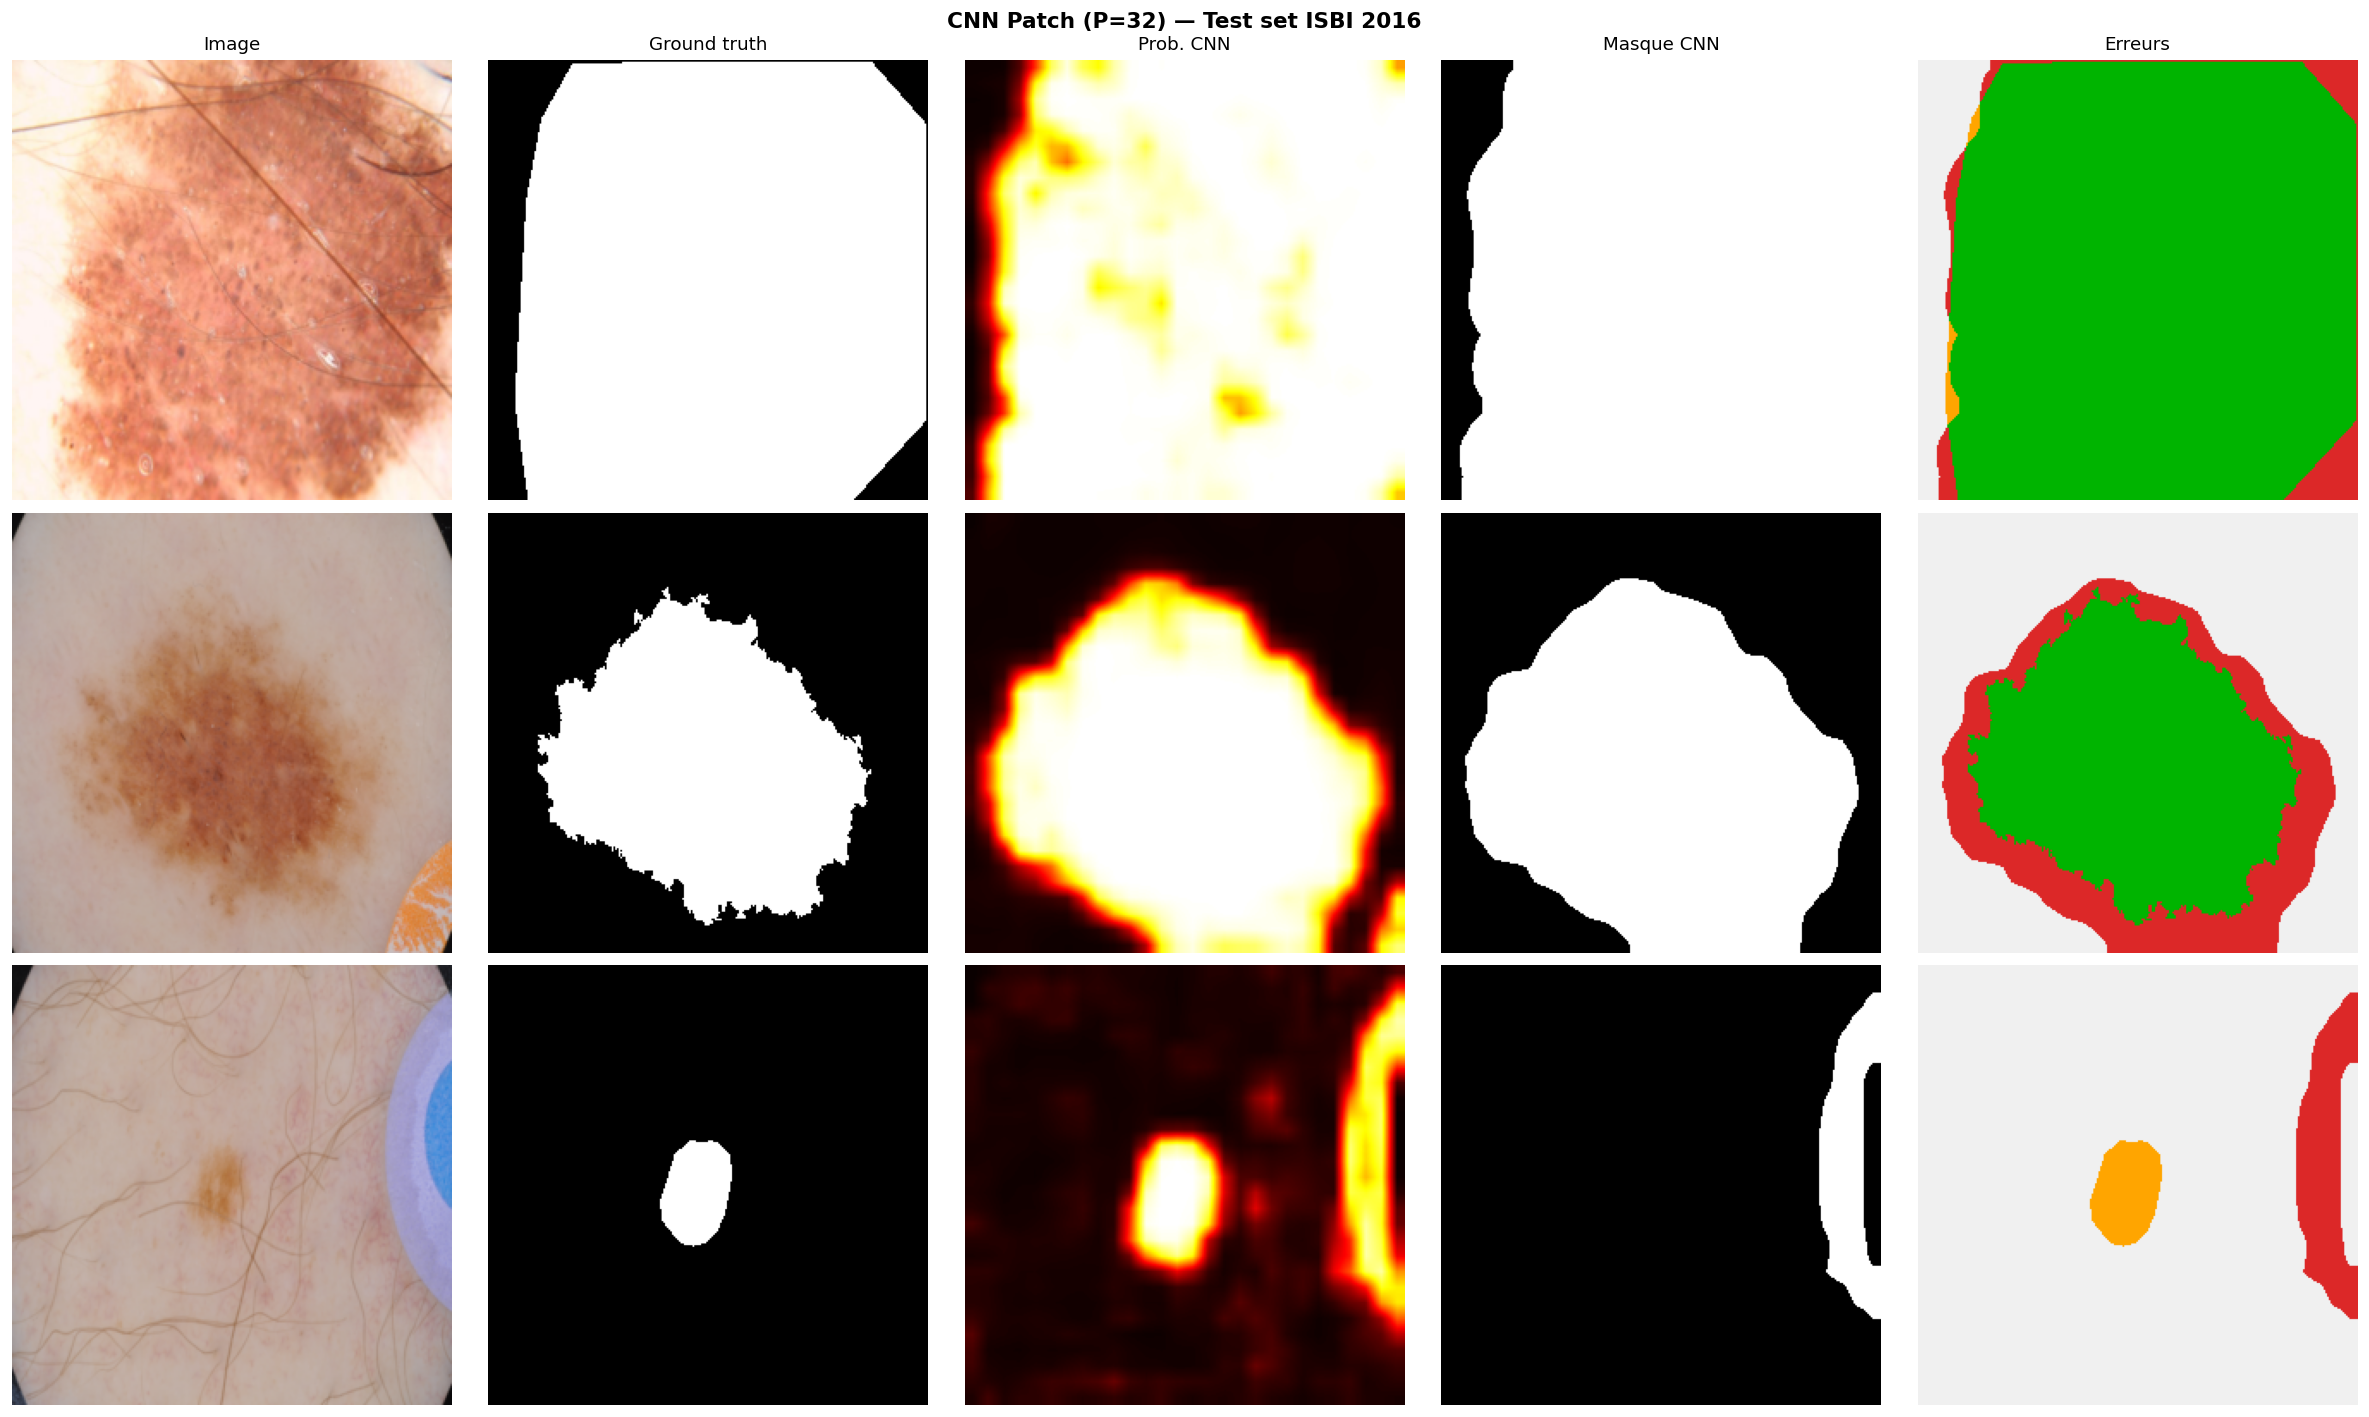

In [19]:
# ═══════════════════════════════════════════════════════════════
# Visualisations qualitatives sur le test set
# ═══════════════════════════════════════════════════════════════

idx_best   = df_test['dice'].idxmax()
idx_worst  = df_test['dice'].idxmin()
idx_median = (df_test['dice'] - df_test['dice'].median()).abs().idxmin()

cases = [('Meilleur', idx_best), ('Median', idx_median), ('Pire', idx_worst)]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
col_titles = ['Image', 'Ground truth', 'Prob. CNN', 'Masque CNN', 'Erreurs']

for row, (title, idx) in enumerate(cases):
    ip, mp = test_official_img[idx], test_official_mask[idx]
    img = load_img(ip)
    gt  = load_mask(mp)
    pred_bin, prob_map = segment_with_cnn(best_model, img, best_ps, best_stride)
    r = df_test.iloc[idx]

    # Carte d'erreurs
    diff_map = np.zeros((*gt.shape, 3), dtype=np.uint8)
    diff_map[(gt == 1) & (pred_bin == 1)] = [0, 180, 0]       # TP vert
    diff_map[(gt == 0) & (pred_bin == 1)] = [220, 40, 40]      # FP rouge
    diff_map[(gt == 1) & (pred_bin == 0)] = [255, 165, 0]      # FN orange
    diff_map[(gt == 0) & (pred_bin == 0)] = [240, 240, 240]    # TN gris

    axes[row, 0].imshow(img)
    axes[row, 0].set_ylabel(f'{title}\nDSC={r["dice"]:.3f}', fontsize=10, fontweight='bold')
    axes[row, 1].imshow(gt, cmap='gray', vmin=0, vmax=1)
    axes[row, 2].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
    axes[row, 3].imshow(pred_bin, cmap='gray', vmin=0, vmax=1)
    axes[row, 4].imshow(diff_map)

    for j in range(5):
        axes[row, j].axis('off')
        if row == 0:
            axes[row, j].set_title(col_titles[j], fontsize=11)

plt.suptitle(f'CNN Patch (P={best_ps}) — Test set ISBI 2016', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Comparaison avec K-means et U-Net

On charge les résultats des autres approches (sauvegardés en JSON par les notebooks précédents) pour établir un tableau comparatif complet.

In [20]:
# ═══════════════════════════════════════════════════════════════
# Chargement des resultats K-means et U-Net
# ═══════════════════════════════════════════════════════════════

# K-means (depuis results_kmeans.json)
kmeans_path = BASE / 'results_kmeans.json'
kmeans_stats = None
if kmeans_path.exists():
    with open(kmeans_path) as f:
        km_data = json.load(f)
    # Prendre la variante RGB (baseline)
    if 'RGB' in km_data:
        km_agg = km_data['RGB']['aggregate']
        kmeans_stats = {
            'dice_mean': km_agg['dice']['mean'], 'dice_std': km_agg['dice']['std'],
            'iou_mean': km_agg['iou']['mean'], 'iou_std': km_agg['iou']['std'],
            'acc_mean': km_agg['accuracy']['mean'], 'acc_std': km_agg['accuracy']['std'],
            'n_failures': km_agg['n_failures_dsc05'],
        }
        print(f'K-means RGB : DSC={kmeans_stats["dice_mean"]:.3f} (900 train images)')
else:
    print('results_kmeans.json non trouve — resultats K-means non disponibles')

# U-Net (depuis results_test_evaluation.json)
unet_path = BASE / 'results_test_evaluation.json'
unet_stats = {}
if unet_path.exists():
    with open(unet_path) as f:
        unet_data = json.load(f)
    for label, stats in unet_data.items():
        unet_stats[label] = {
            'dice_mean': stats['dice']['mean'], 'dice_std': stats['dice']['std'],
            'iou_mean': stats['iou']['mean'], 'iou_std': stats['iou']['std'],
            'acc_mean': stats['accuracy']['mean'], 'acc_std': stats['accuracy']['std'],
        }
        print(f'U-Net {label} : DSC={stats["dice"]["mean"]:.3f} (379 test images)')
else:
    print('results_test_evaluation.json non trouve — resultats U-Net non disponibles')

# CNN Patch (ce notebook)
cnn_stats = {
    'dice_mean': df_test['dice'].mean(), 'dice_std': df_test['dice'].std(),
    'iou_mean': df_test['iou'].mean(), 'iou_std': df_test['iou'].std(),
    'acc_mean': df_test['accuracy'].mean(), 'acc_std': df_test['accuracy'].std(),
    'n_failures': int((df_test['dice'] < 0.5).sum()),
}
print(f'CNN Patch (P={best_ps}) : DSC={cnn_stats["dice_mean"]:.3f} (379 test images)')

results_kmeans.json non trouve — resultats K-means non disponibles
U-Net FINAL : DSC=0.882 (379 test images)
U-Net baseline_f64-d4-skip-bce+dice : DSC=0.863 (379 test images)
CNN Patch (P=32) : DSC=0.760 (379 test images)


In [21]:
# ═══════════════════════════════════════════════════════════════
# Tableau comparatif
# ═══════════════════════════════════════════════════════════════

print('\n' + '=' * 85)
print(f'{"Methode":<30} {"DSC":>18} {"IoU":>18} {"Accuracy":>18}')
print('=' * 85)

if kmeans_stats:
    s = kmeans_stats
    print(f'{"K-means (RGB, 900 img)":<30} '
          f'{s["dice_mean"]:.3f} +/- {s["dice_std"]:.3f}   '
          f'{s["iou_mean"]:.3f} +/- {s["iou_std"]:.3f}   '
          f'{s["acc_mean"]:.3f} +/- {s["acc_std"]:.3f}')

s = cnn_stats
print(f'{f"CNN Patch (P={best_ps}, test)":<30} '
      f'{s["dice_mean"]:.3f} +/- {s["dice_std"]:.3f}   '
      f'{s["iou_mean"]:.3f} +/- {s["iou_std"]:.3f}   '
      f'{s["acc_mean"]:.3f} +/- {s["acc_std"]:.3f}')

for label, s in unet_stats.items():
    print(f'{f"U-Net {label} (test)":<30} '
          f'{s["dice_mean"]:.3f} +/- {s["dice_std"]:.3f}   '
          f'{s["iou_mean"]:.3f} +/- {s["iou_std"]:.3f}   '
          f'{s["acc_mean"]:.3f} +/- {s["acc_std"]:.3f}')

print('=' * 85)


Methode                                       DSC                IoU           Accuracy
CNN Patch (P=32, test)         0.760 +/- 0.175   0.639 +/- 0.184   0.868 +/- 0.129
U-Net FINAL (test)             0.882 +/- 0.130   0.807 +/- 0.161   0.940 +/- 0.084
U-Net baseline_f64-d4-skip-bce+dice (test) 0.863 +/- 0.143   0.781 +/- 0.174   0.932 +/- 0.093


## 9. Analyse du temps d'inférence

Une limitation majeure de l'approche par patches est le **temps d'inférence**. Contrairement au U-Net qui segmente une image en un seul passage (*forward pass*), le CNN patch doit évaluer $N_{\text{patches}} = \left\lfloor\frac{H-P}{s}\right\rfloor \times \left\lfloor\frac{W-P}{s}\right\rfloor$ patches par image.

In [22]:
# ═══════════════════════════════════════════════════════════════
# Comparaison des temps d'inference
# ═══════════════════════════════════════════════════════════════

# Temps CNN patch (mesure sur 10 images)
sample_imgs = [load_img(p) for p in test_official_img[:10]]

t0 = time.time()
for img in sample_imgs:
    _ = predict_segmentation(best_model, img, best_ps, stride=best_stride)
cnn_time_per_img = (time.time() - t0) / 10

# Temps U-Net (mesure sur 10 images)
unet_model_path = SAVE_DIR / 'FINAL.keras'
unet_time_per_img = None
if unet_model_path.exists():
    from tensorflow.keras import backend as K
    unet_model = tf.keras.models.load_model(unet_model_path, custom_objects={
        'dice_coefficient': lambda y_true, y_pred: tf.constant(0.0),
        'iou_coefficient': lambda y_true, y_pred: tf.constant(0.0),
        'dice_loss': lambda y_true, y_pred: tf.constant(0.0),
        'bce_dice_loss': lambda y_true, y_pred: tf.constant(0.0),
    })
    batch = np.stack(sample_imgs)
    # Warmup
    _ = unet_model.predict(batch[:1], verbose=0)
    t0 = time.time()
    _ = unet_model.predict(batch, verbose=0)
    unet_time_per_img = (time.time() - t0) / 10
    del unet_model; K.clear_session()

half = best_ps // 2
n_patches = len(np.arange(half, IMG_SIZE-half, best_stride)) ** 2

print(f'Temps d\'inference par image (256x256) :')
print(f'  CNN Patch (P={best_ps}, stride={best_stride}) : {cnn_time_per_img:.3f}s  ({n_patches} patches)')
if unet_time_per_img:
    print(f'  U-Net (1 forward pass)               : {unet_time_per_img:.3f}s')
    print(f'  Ratio CNN/U-Net                       : x{cnn_time_per_img/unet_time_per_img:.0f}')

Temps d'inference par image (256x256) :
  CNN Patch (P=32, stride=8) : 0.186s  (784 patches)
  U-Net (1 forward pass)               : 1.831s
  Ratio CNN/U-Net                       : x0


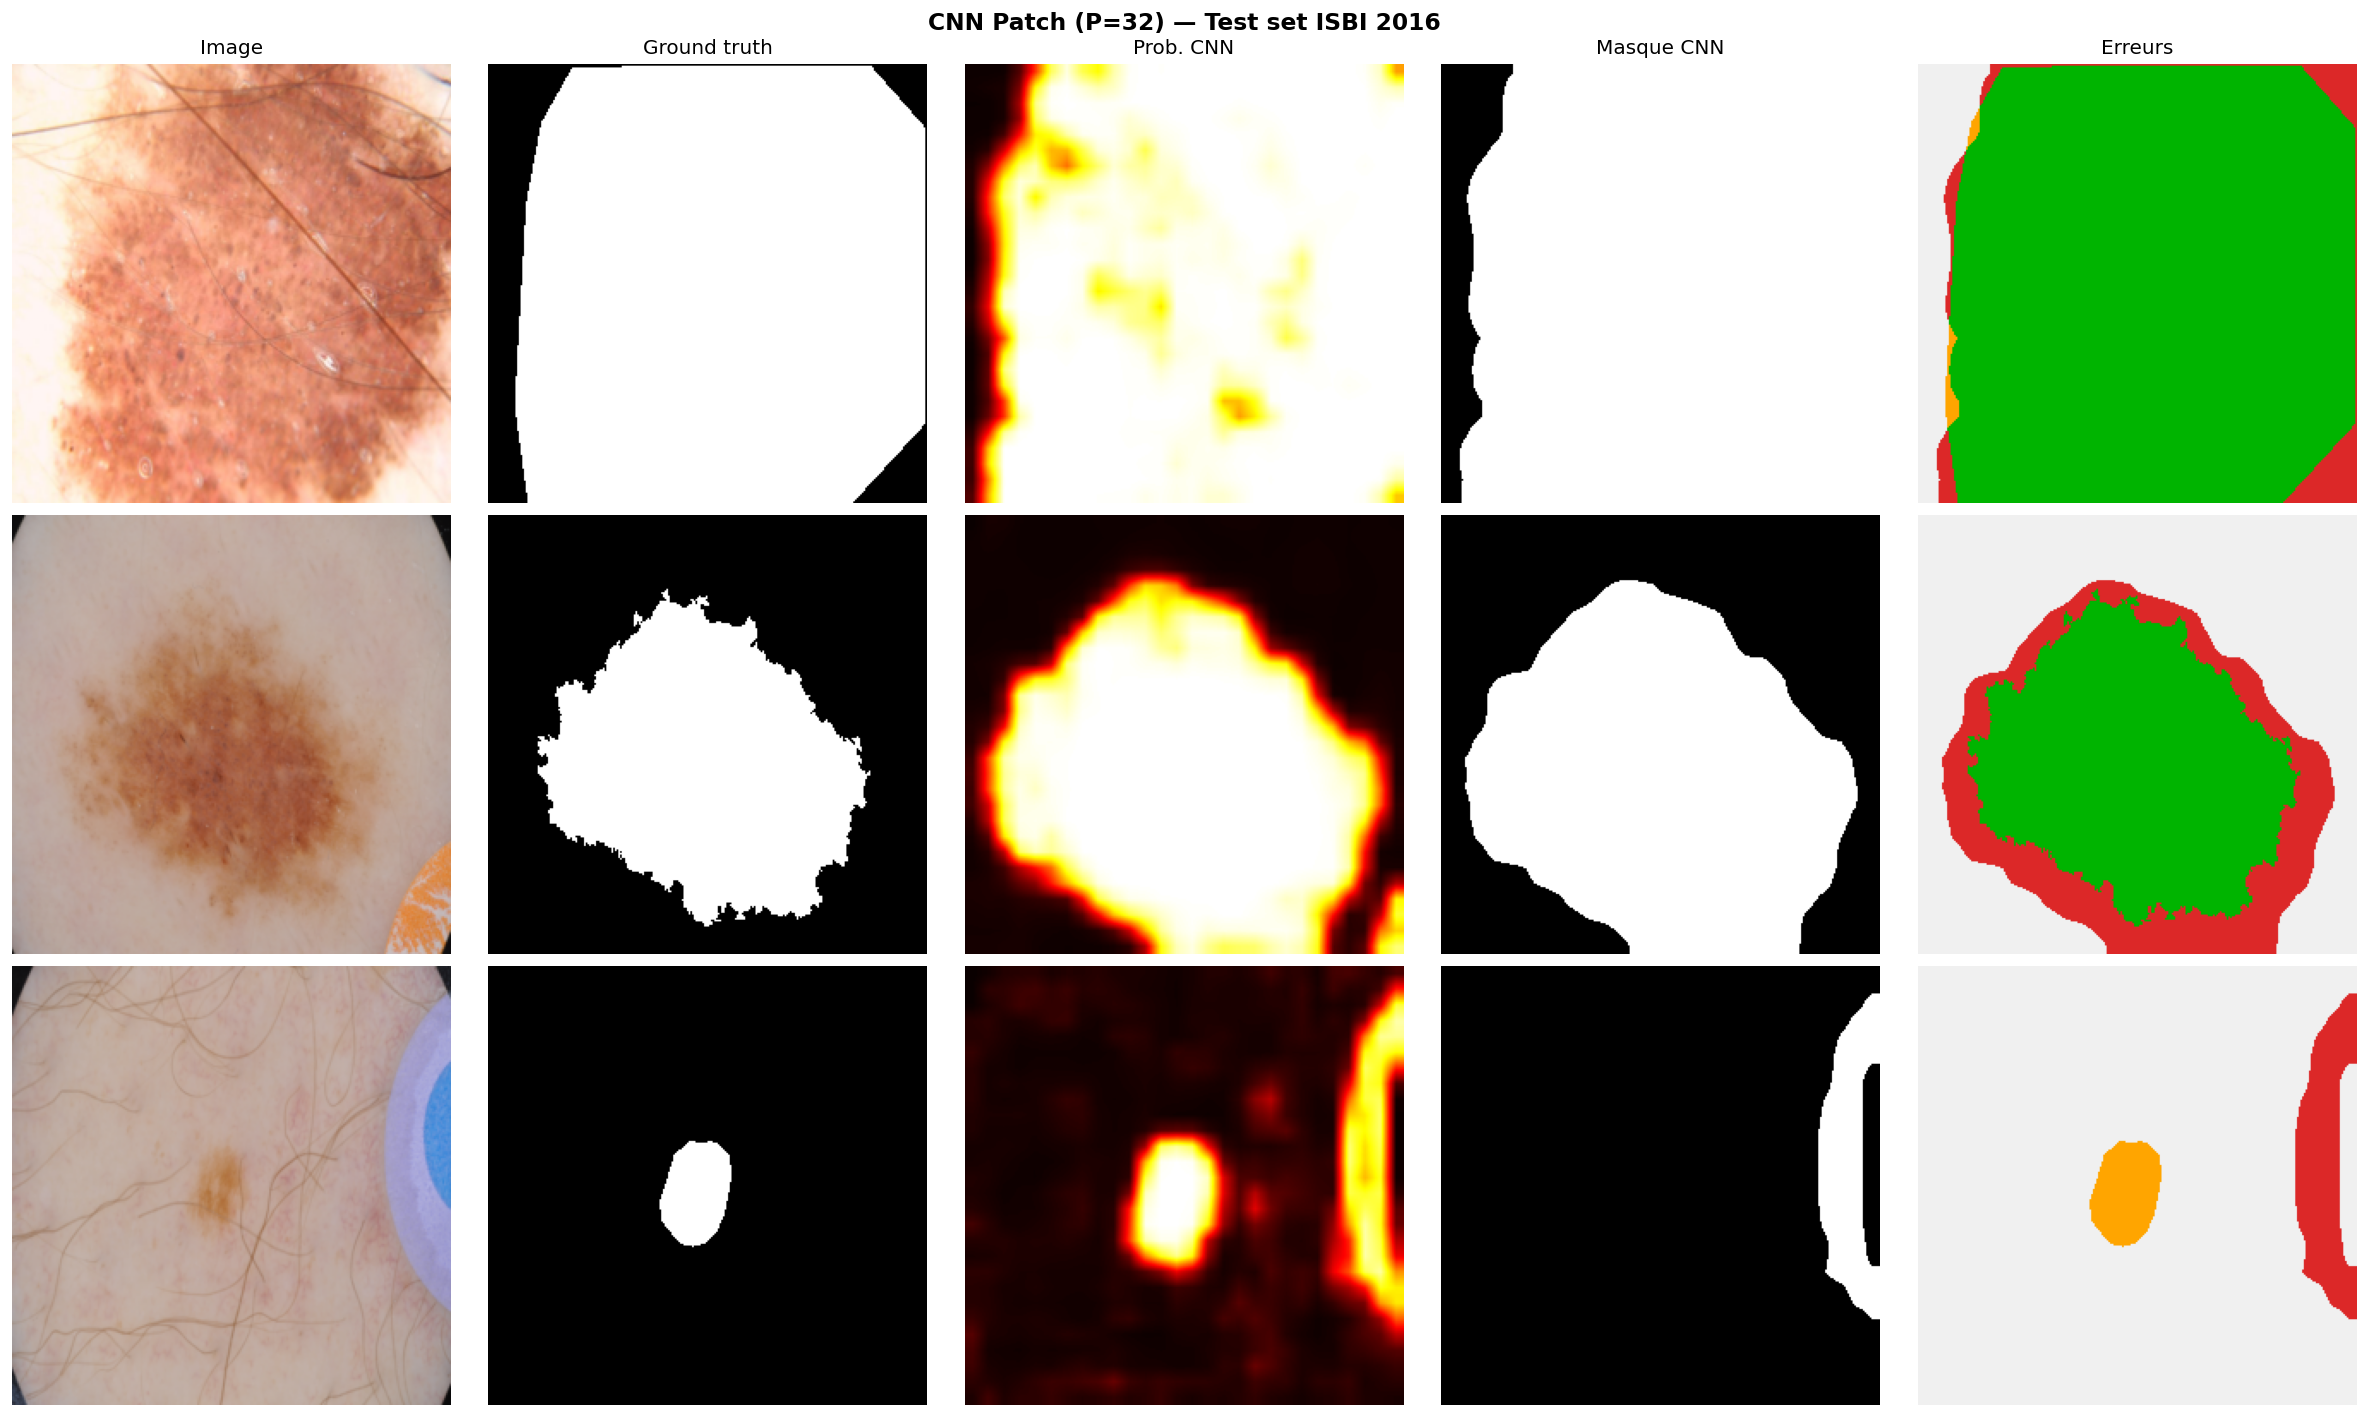

Sauvegarde : figures_cnn/fig_cnn_patch_qualitative.pdf


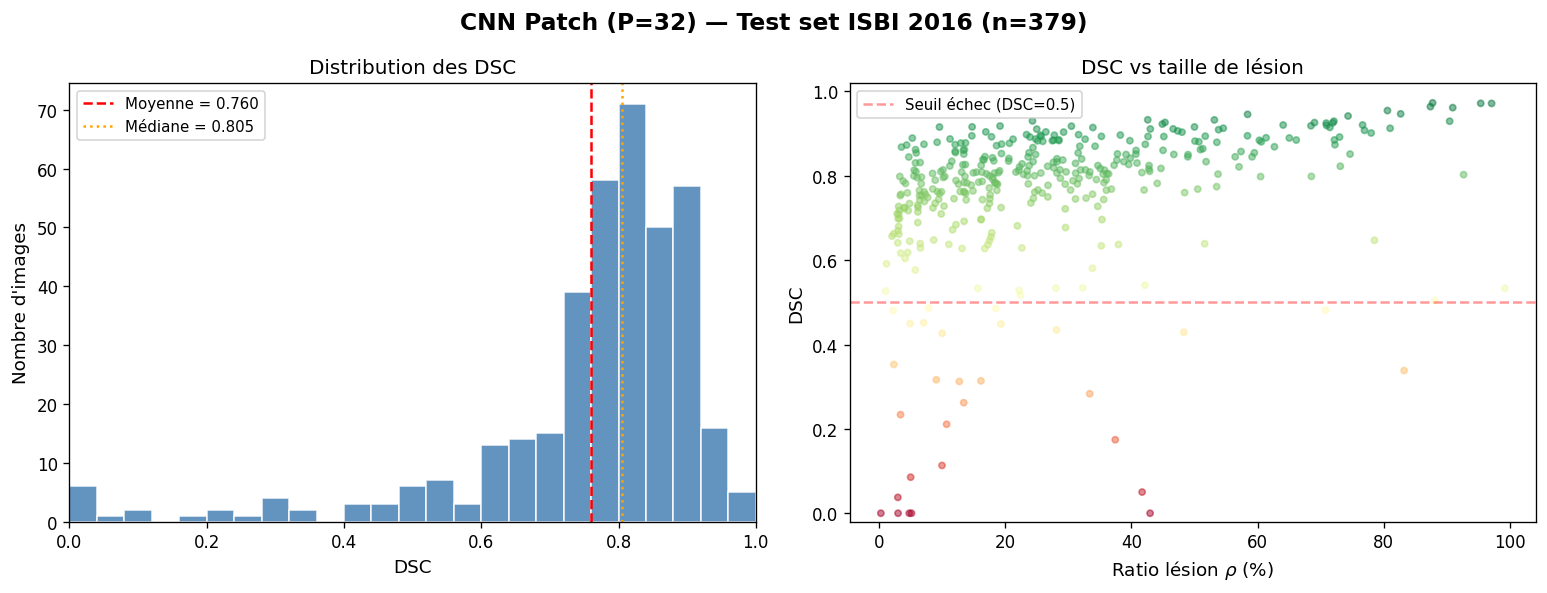

Sauvegarde : figures_cnn/fig_cnn_patch_distribution.pdf


In [27]:
# ═══════════════════════════════════════════════════════════════                                                                                          
# Sauvegarde des figures pour le memoire (Overleaf)                                                                                                      
# ═══════════════════════════════════════════════════════════════                                                                                          
                                                                                                                                                       
FIG_DIR = Path('figures_cnn')
FIG_DIR.mkdir(exist_ok=True)                                                                                                              

# --- Figure 1 : Exemples qualitatifs (meilleur / median / pire) ---

idx_best   = df_test['dice'].idxmax()
idx_worst  = df_test['dice'].idxmin()
idx_median = (df_test['dice'] - df_test['dice'].median()).abs().idxmin()

cases = [('Meilleur', idx_best), ('Médian', idx_median), ('Pire', idx_worst)]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
col_titles = ['Image', 'Ground truth', 'Prob. CNN', 'Masque CNN', 'Erreurs']

for row, (title, idx) in enumerate(cases):
  ip, mp = test_official_img[idx], test_official_mask[idx]
  img = load_img(ip)
  gt  = load_mask(mp)
  pred_bin, prob_map = segment_with_cnn(best_model, img, best_ps, best_stride)
  r = df_test.iloc[idx]

  # Carte d'erreurs
  diff_map = np.zeros((*gt.shape, 3), dtype=np.uint8)
  diff_map[(gt == 1) & (pred_bin == 1)] = [0, 180, 0]       # VP vert
  diff_map[(gt == 0) & (pred_bin == 1)] = [220, 40, 40]      # FP rouge
  diff_map[(gt == 1) & (pred_bin == 0)] = [255, 165, 0]      # FN orange
  diff_map[(gt == 0) & (pred_bin == 0)] = [240, 240, 240]    # VN gris

  axes[row, 0].imshow(img)
  axes[row, 0].set_ylabel(f'{title}\nDSC={r["dice"]:.3f}', fontsize=11, fontweight='bold')
  axes[row, 1].imshow(gt, cmap='gray', vmin=0, vmax=1)
  axes[row, 2].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
  axes[row, 3].imshow(pred_bin, cmap='gray', vmin=0, vmax=1)
  axes[row, 4].imshow(diff_map)

  for j in range(5):
      axes[row, j].axis('off')
      if row == 0:
          axes[row, j].set_title(col_titles[j], fontsize=12)

plt.suptitle(f'CNN Patch (P={best_ps}) — Test set ISBI 2016', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_cnn_patch_qualitative.pdf', bbox_inches='tight', dpi=150)
plt.show()
print(f'Sauvegarde : {FIG_DIR / "fig_cnn_patch_qualitative.pdf"}')

# --- Figure 2 : Distribution des DSC (histogramme + scatter DSC vs rho) ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bins = np.linspace(0, 1, 26)
ax1.hist(df_test['dice'], bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(df_test['dice'].mean(), color='red', linestyle='--', linewidth=1.5,
          label=f'Moyenne = {df_test["dice"].mean():.3f}')
ax1.axvline(df_test['dice'].median(), color='orange', linestyle=':', linewidth=1.5,
          label=f'Médiane = {df_test["dice"].median():.3f}')
ax1.set_xlabel('DSC', fontsize=11)
ax1.set_ylabel("Nombre d'images", fontsize=11)
ax1.set_title('Distribution des DSC', fontsize=12)
ax1.legend(fontsize=9)
ax1.set_xlim(0, 1)

sc = ax2.scatter(df_test['rho'] * 100, df_test['dice'], s=14, alpha=0.5,
               c=df_test['dice'], cmap='RdYlGn', vmin=0, vmax=1)
ax2.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='Seuil échec (DSC=0.5)')
ax2.set_xlabel(r'Ratio lésion $\rho$ (%)', fontsize=11)
ax2.set_ylabel('DSC', fontsize=11)
ax2.set_title(r'DSC vs taille de lésion', fontsize=12)
ax2.set_ylim(-0.02, 1.02)
ax2.legend(fontsize=9)

plt.suptitle(f'CNN Patch (P={best_ps}) — Test set ISBI 2016 (n={len(df_test)})',
           fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_cnn_patch_distribution.pdf', bbox_inches='tight', dpi=150)
plt.show()
print(f'Sauvegarde : {FIG_DIR / "fig_cnn_patch_distribution.pdf"}')

## 10. Discussion et conclusions

### Résultats clés

Le CNN patch-based se positionne, comme attendu, entre le K-means et le U-Net :

1. **Gain par rapport au K-means** : les convolutions apprises capturent des motifs locaux (texture, gradient, couleur) que le simple clustering colorimétrique ne peut pas exploiter. La supervision permet aussi de s'affranchir de l'heuristique « cluster sombre = lésion ».

2. **Écart avec le U-Net** : l'absence de contexte global (l'image entière n'est jamais vue) limite la capacité du modèle à :
   - distinguer les artefacts sombres (bordures de loupe, poils) de la lésion
   - maintenir la cohérence spatiale du masque (contours réguliers)
   - s'adapter à la taille variable des lésions

### Limitations structurelles de l'approche par patches

| Limitation | Conséquence | Solution (→ U-Net) |
|-----------|------------|--------------------|
| Champ réceptif local ($P \times P$) | Pas de contexte global | Encodeur avec downsampling |
| Pas de cohérence spatiale | Masque bruité, bords irréguliers | Skip connections + décodeur |
| Inférence lente ($N$ passes) | Inutilisable en temps réel | 1 seul forward pass |
| Classification binaire (pixel) | Pas de carte de probabilité dense | Sortie dense (pixel-wise) |

### Conclusion

Ce notebook démontre que l'introduction des convolutions et de la supervision apporte un gain significatif par rapport au K-means, validant l'hypothèse que les features apprises surpassent les features colorimétriques brutes. Cependant, l'approche par patches reste fondamentalement limitée par son champ réceptif local et son absence de modélisation spatiale globale. Ces limitations motivent directement l'adoption d'architectures encodeur-décodeur comme le U-Net, qui intègrent contexte global et détails locaux via les skip connections.

In [23]:
# ═══════════════════════════════════════════════════════════════
# Tableau LaTeX pour le memoire
# ═══════════════════════════════════════════════════════════════

print('% ── Tableau LaTeX : Ablation taille de patch ──')
print(r'\begin{table}[H]')
print(r'\centering')
print(r'\caption{Étude d\'ablation de la taille de patch $P$ pour le CNN patch-based (validation, $n = 180$).}')
print(r'\label{tab:cnn_patch_ablation}')
print(r'\begin{tabular}{l r r r r r}')
print(r'\toprule')
print(r'\textbf{Patch $P$} & \textbf{Params} & \textbf{DSC} & \textbf{IoU} & \textbf{Acc. patch} & \textbf{Échecs} \\')
print(r'\midrule')
for ps, r in ablation_results.items():
    print(f'${ps} \\times {ps}$ & {r["params"]:,} & '
          f'${r["val_dice_mean"]:.3f} \\pm {r["val_dice_std"]:.3f}$ & '
          f'${r["val_iou_mean"]:.3f} \\pm {r["val_iou_std"]:.3f}$ & '
          f'{r["best_val_acc"]:.3f} & {r["n_failures"]} \\\\')
print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\end{table}')

print()
print('% ── Tableau LaTeX : Comparaison des 3 approches (test set) ──')
print(r'\begin{table}[H]')
print(r'\centering')
print(r'\caption{Comparaison des approches de segmentation sur le jeu de test ISBI~2016 ($n = 379$).}')
print(r'\label{tab:comparatif_3_methodes}')
print(r'\begin{tabular}{l r r r}')
print(r'\toprule')
print(r'\textbf{Méthode} & \textbf{DSC} & \textbf{IoU} & \textbf{Pixel Accuracy} \\')
print(r'\midrule')
if kmeans_stats:
    s = kmeans_stats
    print(f'$K$-means (RGB) & ${s["dice_mean"]:.3f} \\pm {s["dice_std"]:.3f}$ & '
          f'${s["iou_mean"]:.3f} \\pm {s["iou_std"]:.3f}$ & '
          f'${s["acc_mean"]:.3f} \\pm {s["acc_std"]:.3f}$ \\\\')
s = cnn_stats
print(f'CNN Patch ($P={best_ps}$) & ${s["dice_mean"]:.3f} \\pm {s["dice_std"]:.3f}$ & '
      f'${s["iou_mean"]:.3f} \\pm {s["iou_std"]:.3f}$ & '
      f'${s["acc_mean"]:.3f} \\pm {s["acc_std"]:.3f}$ \\\\')
for label, s in unet_stats.items():
    print(f'U-Net ({label}) & ${s["dice_mean"]:.3f} \\pm {s["dice_std"]:.3f}$ & '
          f'${s["iou_mean"]:.3f} \\pm {s["iou_std"]:.3f}$ & '
          f'${s["acc_mean"]:.3f} \\pm {s["acc_std"]:.3f}$ \\\\')
print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\end{table}')

% ── Tableau LaTeX : Ablation taille de patch ──
\begin{table}[H]
\centering
\caption{Étude d\'ablation de la taille de patch $P$ pour le CNN patch-based (validation, $n = 180$).}
\label{tab:cnn_patch_ablation}
\begin{tabular}{l r r r r r}
\toprule
\textbf{Patch $P$} & \textbf{Params} & \textbf{DSC} & \textbf{IoU} & \textbf{Acc. patch} & \textbf{Échecs} \\
\midrule
$32 \times 32$ & 147,745 & $0.762 \pm 0.142$ & $0.633 \pm 0.159$ & 0.915 & 9 \\
$48 \times 48$ & 147,745 & $0.731 \pm 0.146$ & $0.593 \pm 0.157$ & 0.912 & 11 \\
$64 \times 64$ & 147,745 & $0.705 \pm 0.136$ & $0.559 \pm 0.148$ & 0.911 & 12 \\
\bottomrule
\end{tabular}
\end{table}

% ── Tableau LaTeX : Comparaison des 3 approches (test set) ──
\begin{table}[H]
\centering
\caption{Comparaison des approches de segmentation sur le jeu de test ISBI~2016 ($n = 379$).}
\label{tab:comparatif_3_methodes}
\begin{tabular}{l r r r}
\toprule
\textbf{Méthode} & \textbf{DSC} & \textbf{IoU} & \textbf{Pixel Accuracy} \\
\midrule
CNN Patch ($P

In [25]:
# ═══════════════════════════════════════════════════════════════
 # Impact du post-traitement (keep_largest_component)                                                                                                       
# ═══════════════════════════════════════════════════════════════

metrics_with, metrics_without = [], []

for ip, mp in zip(val_img, val_mask):
  img = load_img(ip)
  gt  = load_mask(mp)
  prob_map = predict_segmentation(model, img, PATCH_SIZE, stride=STRIDE)
  mask_raw = (prob_map >= 0.5).astype(np.float32)
  mask_pp  = keep_largest_component(mask_raw)

  metrics_without.append(compute_all_metrics(gt, mask_raw))
  metrics_with.append(compute_all_metrics(gt, mask_pp))

df_without = pd.DataFrame(metrics_without)
df_with    = pd.DataFrame(metrics_with)

print('Impact du post-traitement (keep_largest_component) sur la validation :')
print(f'{"Metrique":<12} {"Sans PP":>18} {"Avec PP":>18} {"Delta":>10}')
print('=' * 60)
for col in ['dice', 'iou', 'accuracy', 'precision', 'recall']:
  m1 = df_without[col].mean()
  m2 = df_with[col].mean()
  delta = m2 - m1
  print(f'{col.upper():<12} {m1:.4f} +/- {df_without[col].std():.4f}   '
        f'{m2:.4f} +/- {df_with[col].std():.4f}   {delta:+.4f}')

n_fail_without = (df_without['dice'] < 0.5).sum()
n_fail_with    = (df_with['dice'] < 0.5).sum()
print(f'\nEchecs (DSC<0.5) : {n_fail_without} -> {n_fail_with}')

Impact du post-traitement (keep_largest_component) sur la validation :
Metrique                Sans PP            Avec PP      Delta
DICE         0.7235 +/- 0.1408   0.7308 +/- 0.1455   +0.0073
IOU          0.5840 +/- 0.1584   0.5934 +/- 0.1572   +0.0094
ACCURACY     0.8503 +/- 0.1166   0.8581 +/- 0.1142   +0.0078
PRECISION    0.6160 +/- 0.1687   0.6312 +/- 0.1649   +0.0152
RECALL       0.9436 +/- 0.1387   0.9319 +/- 0.1732   -0.0117

Echecs (DSC<0.5) : 15 -> 11
